# GRASP Parameter Study

Controlled OFAT (one-factor-at-a-time) analysis of GRASP parameters: `alpha`, `max_iterations`, `construction_score`, `local_search`.

Data source: JSONL files under `results/{DATASET}_*/runs_*.jsonl`, produced by the 4 sweep configs in `configs/grasp_*_sweep.yaml`.

To (re)generate data:
```bash
python3 run_experiments.py configs/grasp_alpha_sweep.yaml
python3 run_experiments.py configs/grasp_iterations_sweep.yaml
python3 run_experiments.py configs/grasp_construction_sweep.yaml
python3 run_experiments.py configs/grasp_localsearch_sweep.yaml
```

Each config uses `repetitions: 5` (five seeds per instance) so we can measure variance, which is a first-class metric for a stochastic method like GRASP.

In [14]:
# ============================================================
# Configuration — edit these to switch dataset or toggle options
# ============================================================
from pathlib import Path

DATASET = "a"                # "a" | "b" | "x"
RESULTS_ROOT = Path("../results")
DATASETS_ROOT = Path("../datasets")
BEST_OBJ_PATH = Path("../best_solutions/best_objectives.csv")
NORMALIZE_TO_BEST = True     # plot objective / best_known when True and available

# Algorithm-name prefixes per sweep (match configs/grasp_*_sweep.yaml)
SWEEP_PREFIXES = {
    "alpha":        "grasp_alpha_",
    "iterations":   "grasp_iter_",
    "construction": "grasp_cons_",
    "localsearch":  "grasp_ls_",
}

In [15]:
import json
import sys
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("..").resolve()))
from problems.base import load_instance

try:
    from scipy.stats import wilcoxon
    HAVE_SCIPY = True
except ImportError:
    HAVE_SCIPY = False

## Helpers

Pure functions for loading and aggregating run data. Kept local to the notebook so it stays runnable without touching `runner/consolidate.py`.

In [16]:
def load_sweep_jsonl(dataset: str, prefix: str) -> pd.DataFrame:
    """Load all JSONL runs for `dataset` whose algorithm name starts with `prefix`.
    Flattens `params` into columns."""
    pattern = str(RESULTS_ROOT / f"{dataset}_*" / "runs_*.jsonl")
    records = []
    for path in sorted(glob(pattern)):
        with open(path) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                r = json.loads(line)
                if r.get("algorithm", "").startswith(prefix):
                    records.append(r)
    if not records:
        return pd.DataFrame()
    df = pd.DataFrame(records)
    params_df = pd.json_normalize(df["params"])
    return pd.concat([df.drop(columns=["params"]), params_df], axis=1)


def load_instance_meta(dataset: str) -> pd.DataFrame:
    """Per-instance size metadata: nOrders, nItems, nAisles, lb, ub, size_bucket."""
    rows = []
    for path in sorted((DATASETS_ROOT / dataset).glob("*.txt")):
        inst = load_instance(str(path))
        rows.append({
            "instance": path.name,
            "nOrders": inst.nOrders,
            "nItems": inst.nItems,
            "nAisles": inst.nAisles,
            "lb": inst.lb,
            "ub": inst.ub,
            "size_proxy": inst.nOrders * inst.nAisles,
        })
    meta = pd.DataFrame(rows)
    if len(meta) >= 3:
        meta["size_bucket"] = pd.qcut(
            meta["size_proxy"], q=3, labels=["small", "medium", "large"],
            duplicates="drop",
        )
    else:
        meta["size_bucket"] = "all"
    return meta


def load_best_objectives(dataset: str) -> pd.DataFrame:
    """Best-known objective per instance (empty frame if file missing)."""
    if not BEST_OBJ_PATH.exists():
        return pd.DataFrame(columns=["instance", "best_objective"])
    best = pd.read_csv(BEST_OBJ_PATH)
    if "dataset" in best.columns:
        best = best[best["dataset"] == dataset]
    return best[["instance", "best_objective"]]


def normalize_objective(df: pd.DataFrame, best: pd.DataFrame) -> tuple[pd.DataFrame, str]:
    """Add a `y` column = objective / best (if enabled and available), else objective."""
    df = df.merge(best, on="instance", how="left")
    if NORMALIZE_TO_BEST and df["best_objective"].notna().any():
        df["y"] = df["objective"] / df["best_objective"]
        return df, "objective / best_known"
    df["y"] = df["objective"]
    return df, "objective"


def aggregate(df: pd.DataFrame, by: list[str]) -> pd.DataFrame:
    """Aggregate runs → mean, std, min, max, median of objective (or `y`) and time."""
    if df.empty:
        return df
    y_col = "y" if "y" in df.columns else "objective"
    agg = df.groupby(by, observed=True).agg(
        obj_mean=(y_col, "mean"),
        obj_std=(y_col, "std"),
        obj_min=(y_col, "min"),
        obj_max=(y_col, "max"),
        obj_median=(y_col, "median"),
        time_mean=("time_s", "mean"),
        time_std=("time_s", "std"),
        n_runs=(y_col, "size"),
        feasible_rate=("feasible", "mean"),
    ).reset_index()
    agg["obj_std"] = agg["obj_std"].fillna(0.0)
    agg["time_std"] = agg["time_std"].fillna(0.0)
    agg["cov"] = agg["obj_std"] / agg["obj_mean"].replace(0, np.nan)
    return agg


plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## Load all sweeps and metadata

In [17]:
sweeps = {name: load_sweep_jsonl(DATASET, prefix) for name, prefix in SWEEP_PREFIXES.items()}
for name, df in sweeps.items():
    n_runs = len(df)
    n_cfg = df["algorithm"].nunique() if n_runs else 0
    n_inst = df["instance"].nunique() if n_runs else 0
    status = "OK" if n_runs else "(no data — run the sweep config)"
    print(f"  {name:<14} runs={n_runs:>5}  configs={n_cfg:>2}  instances={n_inst:>3}  {status}")

meta = load_instance_meta(DATASET)
best = load_best_objectives(DATASET)
print(f"\nDataset '{DATASET}': {len(meta)} instances, {len(best)} with best-known objectives.")
meta.head()

  alpha          runs=  700  configs= 7  instances= 20  OK
  iterations     runs=    0  configs= 0  instances=  0  (no data — run the sweep config)
  construction   runs=    0  configs= 0  instances=  0  (no data — run the sweep config)
  localsearch    runs=  300  configs= 3  instances= 20  OK

Dataset 'a': 20 instances, 20 with best-known objectives.


,instance,nOrders,nItems,nAisles,lb,ub,size_proxy,size_bucket
0,instance_0001.txt,61,155,116,30,68,7076,small
1,instance_0002.txt,7,7,33,0,2,231,small
2,instance_0003.txt,82,246,124,33,106,10168,small
3,instance_0004.txt,16,59,91,4,40,1456,small
4,instance_0005.txt,2625,6407,161,1322,4395,422625,large


## 1. Sensitivity to `alpha` (greedy ↔ random)

**Question.** Which α maximizes the mean objective? Is there the classical "sweet spot" in the middle?

**Interpretation.**
- α = 0 → pure greedy (deterministic; zero variance across seeds)
- α = 1 → pure random from the feasible candidate list
- A good GRASP usually peaks at moderate α (0.1–0.3) — enough diversity to escape local optima, not so much that solutions degrade.

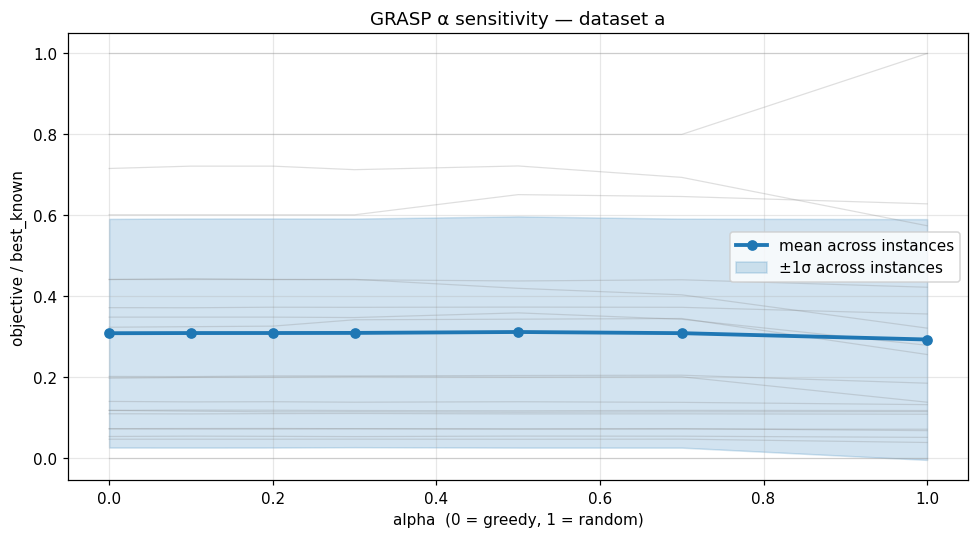

Best α per instance (by mean objective):
         instance  alpha  obj_mean
instance_0001.txt    0.5  0.359231
instance_0002.txt    0.0  1.000000
instance_0003.txt    0.3  0.442109
instance_0004.txt    0.5  0.651354
instance_0005.txt    0.7  0.205239
instance_0006.txt    0.3  0.047255
instance_0007.txt    0.2  0.073642
instance_0008.txt    0.3  0.201724
instance_0009.txt    0.5  0.722157
instance_0010.txt    0.5  0.373498
instance_0011.txt    0.1  0.443608
instance_0012.txt    0.7  0.345335
instance_0013.txt    0.3  0.110671
instance_0014.txt    0.0  0.000000
instance_0015.txt    0.3  0.072891
instance_0016.txt    0.1  0.119050
instance_0017.txt    0.0  0.118229
instance_0018.txt    0.0  0.140473
instance_0019.txt    0.5  0.054835
instance_0020.txt    1.0  1.000000

Overall winner counts:
alpha
0.0    4
0.1    2
0.2    1
0.3    5
0.5    5
0.7    2
1.0    1
Name: count, dtype: int64


In [18]:
df = sweeps["alpha"]
if df.empty:
    print("No data for alpha sweep.")
else:
    df, ylabel = normalize_objective(df, best)
    per_inst = aggregate(df, ["alpha", "instance"])

    fig, ax = plt.subplots(figsize=(9, 5))
    for _, sub in per_inst.groupby("instance"):
        sub = sub.sort_values("alpha")
        ax.plot(sub["alpha"], sub["obj_mean"], color="tab:gray", alpha=0.25, linewidth=0.8)

    overall = per_inst.groupby("alpha").agg(
        mean=("obj_mean", "mean"), std=("obj_mean", "std")
    ).reset_index()
    ax.plot(overall["alpha"], overall["mean"], color="tab:blue",
            linewidth=2.5, marker="o", label="mean across instances")
    ax.fill_between(overall["alpha"],
                    overall["mean"] - overall["std"],
                    overall["mean"] + overall["std"],
                    alpha=0.2, color="tab:blue", label="±1σ across instances")
    ax.set_xlabel("alpha  (0 = greedy, 1 = random)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"GRASP α sensitivity — dataset {DATASET}")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Best α per instance
    idx = per_inst.groupby("instance")["obj_mean"].idxmax()
    best_alpha = per_inst.loc[idx, ["instance", "alpha", "obj_mean"]].sort_values("instance")
    print("Best α per instance (by mean objective):")
    print(best_alpha.to_string(index=False))
    print("\nOverall winner counts:")
    print(best_alpha["alpha"].value_counts().sort_index())

## 2. Diminishing returns on `max_iterations`

**Question.** Beyond which N does adding more iterations stop paying off?

**What to expect.** A concave curve plateauing at some knee. The knee is a budget signal — spend the rest of the time on local search or a better construction.

In [19]:
df = sweeps["iterations"]
if df.empty:
    print("No data for iterations sweep.")
else:
    df, ylabel = normalize_objective(df, best)
    per_inst = aggregate(df, ["max_iterations", "instance"])
    overall = per_inst.groupby("max_iterations").agg(
        mean=("obj_mean", "mean"), std=("obj_mean", "std")
    ).reset_index().sort_values("max_iterations")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
    for _, sub in per_inst.groupby("instance"):
        sub = sub.sort_values("max_iterations")
        ax1.plot(sub["max_iterations"], sub["obj_mean"],
                 color="tab:gray", alpha=0.25, linewidth=0.8)
    ax1.plot(overall["max_iterations"], overall["mean"],
             color="tab:blue", linewidth=2.5, marker="o", label="mean")
    ax1.fill_between(overall["max_iterations"],
                     overall["mean"] - overall["std"],
                     overall["mean"] + overall["std"],
                     alpha=0.2, color="tab:blue", label="±1σ")
    ax1.set_xscale("log")
    ax1.set_xlabel("max_iterations (log scale)")
    ax1.set_ylabel(ylabel)
    ax1.set_title("Diminishing returns on max_iterations")
    ax1.legend()

    # iter_to_95%: smallest max_iter whose mean ≥ 0.95 × observed max
    per_inst = per_inst.sort_values(["instance", "max_iterations"])
    rows = []
    for inst, sub in per_inst.groupby("instance"):
        cap = sub["obj_mean"].max()
        if cap <= 0:
            continue
        cutoff = 0.95 * cap
        qualifying = sub[sub["obj_mean"] >= cutoff]
        rows.append({"instance": inst, "iter_to_95pct": int(qualifying["max_iterations"].min())})
    iter95 = pd.DataFrame(rows)
    if not iter95.empty:
        iter95["iter_to_95pct"].plot.hist(
            bins=list(sorted(df["max_iterations"].unique()) + [10_000]),
            ax=ax2, color="tab:orange", edgecolor="black")
        ax2.set_xscale("log")
        ax2.set_xlabel("smallest max_iter reaching ≥95% of its own max")
        ax2.set_ylabel("# instances")
        ax2.set_title("Budget needed per instance")
    plt.tight_layout()
    plt.show()

    print("Mean objective per max_iterations:")
    print(overall.to_string(index=False))
    if not iter95.empty:
        print("\niter_to_95pct summary:")
        print(iter95["iter_to_95pct"].describe().to_string())

No data for iterations sweep.


## 3. Comparing `construction_score` strategies

**Question.** Do expensive scoring functions (`synergy`, `aisle_cost`) earn their cost vs the cheap `size`?

**Two views.**
1. Boxplot of objectives per strategy (quality distribution).
2. Scatter objective × time — a strategy can be Pareto-dominated.

In [20]:
df = sweeps["construction"]
if df.empty:
    print("No data for construction sweep.")
else:
    df, ylabel = normalize_objective(df, best)
    strategies = sorted(df["construction_score"].unique())
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

    data = [df[df["construction_score"] == s]["y"].values for s in strategies]
    ax1.boxplot(data, tick_labels=strategies, showmeans=True)
    ax1.set_ylabel(ylabel)
    ax1.set_title("Objective distribution")
    ax1.tick_params(axis="x", rotation=20)

    per_cfg = aggregate(df, ["construction_score"])
    ax2.errorbar(per_cfg["time_mean"], per_cfg["obj_mean"],
                 xerr=per_cfg["time_std"], yerr=per_cfg["obj_std"],
                 fmt="o", capsize=3)
    for _, row in per_cfg.iterrows():
        ax2.annotate(row["construction_score"],
                     (row["time_mean"], row["obj_mean"]),
                     textcoords="offset points", xytext=(6, 4), fontsize=8)
    ax2.set_xlabel("mean time per run (s)")
    ax2.set_ylabel(f"mean {ylabel}")
    ax2.set_title("Quality × cost (Pareto view)")
    plt.tight_layout()
    plt.show()

    print("Per-strategy summary:")
    print(per_cfg[["construction_score", "obj_mean", "obj_std", "time_mean", "cov"]].to_string(index=False))

    # Pairwise Wilcoxon on per-instance means
    if HAVE_SCIPY and len(strategies) >= 2:
        print("\nWilcoxon signed-rank (per-instance mean), two-sided p-values:")
        pivot = aggregate(df, ["construction_score", "instance"]).pivot(
            index="instance", columns="construction_score", values="obj_mean"
        ).dropna()
        for i, a in enumerate(strategies):
            for b in strategies[i + 1:]:
                if a in pivot and b in pivot:
                    diffs = pivot[a] - pivot[b]
                    if (diffs != 0).any():
                        stat, p = wilcoxon(pivot[a], pivot[b])
                        print(f"  {a:<18} vs {b:<18}  p = {p:.4f}")
                    else:
                        print(f"  {a:<18} vs {b:<18}  identical")

No data for construction sweep.


## 4. Impact of `local_search`

**Question.** How much does `swap` (1:1 move) or `full` (swap + drop + add) improve over pure multistart (`none`)?

**Plot.** Per-instance Δobjective vs `none`, grouped by LS variant. Positive = improvement.

**Warning.** LS eats time budget — a richer LS with the same `time_limit` may complete fewer GRASP iterations. Compare the time column too.

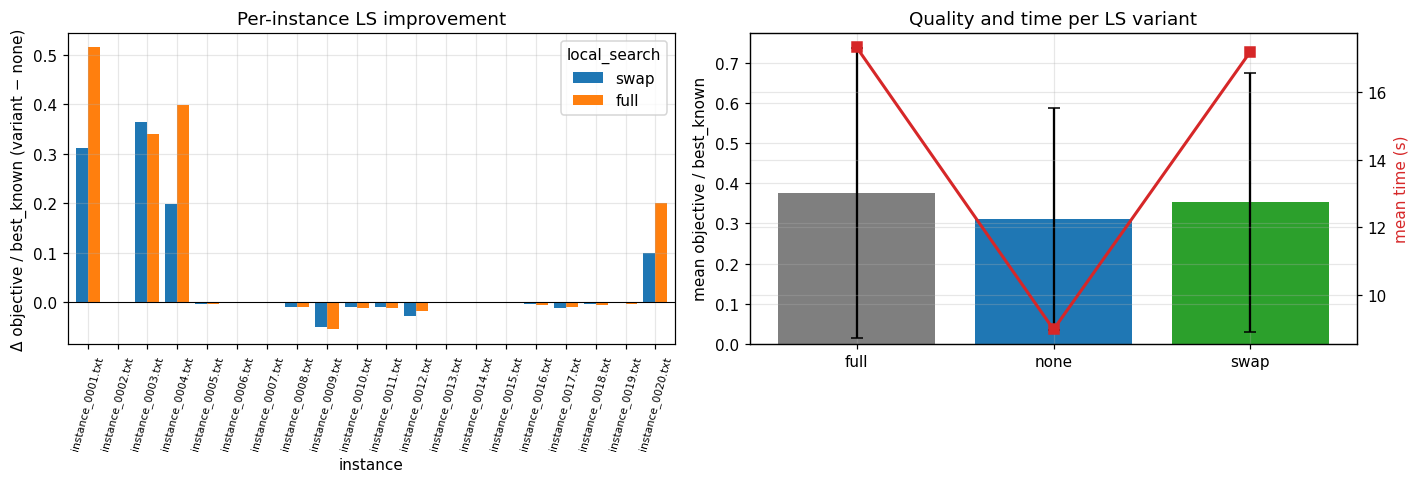

Δ objective summary (mean across instances):
local_search
swap    0.041942
full    0.065823

# instances improved (Δ > 0):
local_search
swap    4
full    4

Per-variant aggregate:
local_search  obj_mean  obj_std  time_mean
        full  0.376634 0.361987  17.336595
        none  0.310810 0.277289   8.974172
        swap  0.352753 0.324076  17.210889


In [21]:
df = sweeps["localsearch"]
if df.empty:
    print("No data for localsearch sweep.")
else:
    df, ylabel = normalize_objective(df, best)
    per_inst = aggregate(df, ["local_search", "instance"])
    pivot_obj = per_inst.pivot(index="instance", columns="local_search", values="obj_mean")

    variants = [v for v in ["swap", "full"] if v in pivot_obj.columns]
    if "none" not in pivot_obj.columns or not variants:
        print("Need at least 'none' + one of {swap, full}; partial data.")
    else:
        delta = pivot_obj[variants].sub(pivot_obj["none"], axis=0)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
        delta.sort_index().plot.bar(ax=ax1, width=0.8)
        ax1.axhline(0, color="black", linewidth=0.7)
        ax1.set_ylabel(f"Δ {ylabel} (variant − none)")
        ax1.set_title("Per-instance LS improvement")
        ax1.tick_params(axis="x", rotation=75, labelsize=7)

        per_cfg = aggregate(df, ["local_search"])
        ax2.bar(per_cfg["local_search"], per_cfg["obj_mean"], yerr=per_cfg["obj_std"],
                capsize=4, color=["tab:gray", "tab:blue", "tab:green"][:len(per_cfg)])
        ax2b = ax2.twinx()
        ax2b.plot(per_cfg["local_search"], per_cfg["time_mean"],
                  color="tab:red", marker="s", linewidth=2, label="time (s)")
        ax2b.set_ylabel("mean time (s)", color="tab:red")
        ax2.set_ylabel(f"mean {ylabel}")
        ax2.set_title("Quality and time per LS variant")
        plt.tight_layout()
        plt.show()

        print("Δ objective summary (mean across instances):")
        print(delta.mean().to_string())
        print("\n# instances improved (Δ > 0):")
        print((delta > 0).sum().to_string())
        print("\nPer-variant aggregate:")
        print(per_cfg[["local_search", "obj_mean", "obj_std", "time_mean"]].to_string(index=False))

## 5. Robustness across seeds

**Question.** Which configurations are most stable — i.e., low coefficient of variation (σ/μ) in objective across the 5 seeds?

A config with high mean but high CoV is risky: a single run might miss the good region entirely.

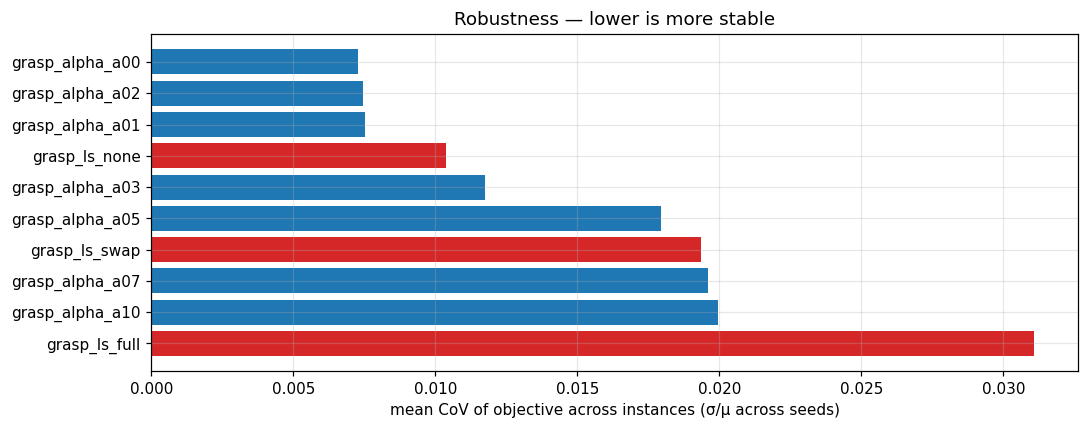

      sweep       algorithm  obj_mean  cov_mean  cov_max
      alpha grasp_alpha_a00  0.308974  0.007270 0.038914
      alpha grasp_alpha_a02  0.309478  0.007465 0.026772
      alpha grasp_alpha_a01  0.309392  0.007521 0.026073
localsearch   grasp_ls_none  0.310810  0.010377 0.035948
      alpha grasp_alpha_a03  0.309733  0.011734 0.045443
      alpha grasp_alpha_a05  0.311985  0.017932 0.099340
localsearch   grasp_ls_swap  0.352753  0.019356 0.079399
      alpha grasp_alpha_a07  0.309109  0.019619 0.083577
      alpha grasp_alpha_a10  0.293437  0.019962 0.076188
localsearch   grasp_ls_full  0.376634  0.031077 0.307720


In [22]:
# CoV per (sweep, algorithm), aggregated across instances
rows = []
for name, df in sweeps.items():
    if df.empty:
        continue
    df, _ = normalize_objective(df, best)
    per_cfg_inst = aggregate(df, ["algorithm", "instance"])
    for algo, sub in per_cfg_inst.groupby("algorithm"):
        rows.append({
            "sweep": name,
            "algorithm": algo,
            "obj_mean": sub["obj_mean"].mean(),
            "cov_mean": sub["cov"].mean(),
            "cov_max": sub["cov"].max(),
        })
robust = pd.DataFrame(rows)

if robust.empty:
    print("No data loaded for any sweep.")
else:
    robust = robust.sort_values("cov_mean")
    fig, ax = plt.subplots(figsize=(10, max(4, 0.25 * len(robust))))
    colors = {"alpha": "tab:blue", "iterations": "tab:orange",
              "construction": "tab:green", "localsearch": "tab:red"}
    ax.barh(robust["algorithm"], robust["cov_mean"],
            color=[colors.get(s, "tab:gray") for s in robust["sweep"]])
    ax.set_xlabel("mean CoV of objective across instances (σ/μ across seeds)")
    ax.set_title("Robustness — lower is more stable")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

    print(robust.to_string(index=False))

## 6. Ranking across all configs

**Question.** Across every config tested (all 4 sweeps pooled), which one wins most often per instance?

Rank each config within each instance (rank 1 = best mean); then report the mean rank.

In [23]:
pooled_frames = []
for name, df in sweeps.items():
    if df.empty:
        continue
    df, _ = normalize_objective(df, best)
    pooled_frames.append(df.assign(sweep=name))

if not pooled_frames:
    print("No data pooled.")
else:
    pooled = pd.concat(pooled_frames, ignore_index=True)
    per_cfg_inst = aggregate(pooled, ["algorithm", "instance"])
    pivot = per_cfg_inst.pivot(index="instance", columns="algorithm", values="obj_mean")
    ranks = pivot.rank(axis=1, ascending=False, method="min")

    rank_summary = pd.DataFrame({
        "mean_rank": ranks.mean().round(2),
        "median_rank": ranks.median(),
        "wins": (ranks == 1).sum().astype(int),
        "top3": (ranks <= 3).sum().astype(int),
        "obj_mean": pivot.mean().round(4),
    }).sort_values("mean_rank")
    print(f"Ranking of {len(rank_summary)} configs across {len(pivot)} instances:\n")
    print(rank_summary.to_string())

Ranking of 10 configs across 20 instances:

                 mean_rank  median_rank  wins  top3  obj_mean
algorithm                                                    
grasp_ls_none         3.30          3.5     7    10    0.3108
grasp_alpha_a02       3.50          4.0     2     9    0.3095
grasp_alpha_a03       3.95          4.0     4     9    0.3097
grasp_alpha_a01       4.10          4.0     4     8    0.3094
grasp_alpha_a00       4.10          5.0     4     7    0.3090
grasp_alpha_a07       4.25          4.0     4     7    0.3091
grasp_alpha_a05       4.35          3.5     3    10    0.3120
grasp_ls_swap         6.20          8.0     3     6    0.3528
grasp_ls_full         6.60          8.5     5     6    0.3766
grasp_alpha_a10       7.70         10.0     3     4    0.2934


## 7. Pareto frontier — quality × time

Each config is a point: mean objective vs mean wall-clock time across all instances. Configs on the upper-left frontier are non-dominated.

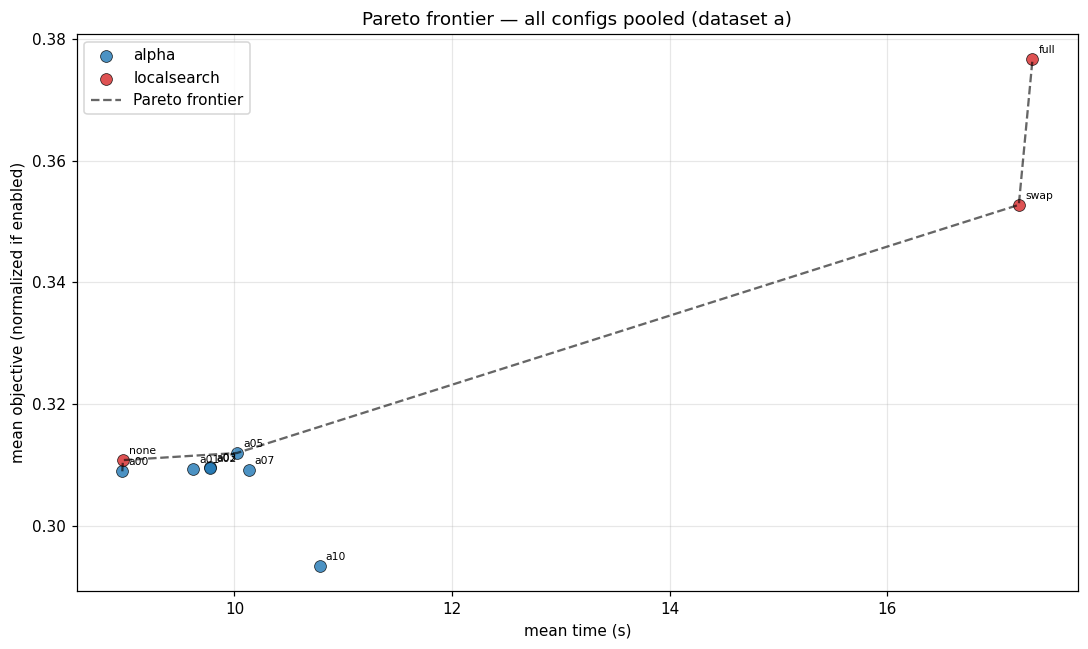

Configs on the Pareto frontier:
      algorithm       sweep  obj_mean  time_mean
grasp_alpha_a00       alpha  0.308974   8.968624
  grasp_ls_none localsearch  0.310810   8.974172
grasp_alpha_a05       alpha  0.311985  10.022799
  grasp_ls_swap localsearch  0.352753  17.210889
  grasp_ls_full localsearch  0.376634  17.336595


In [24]:
if not pooled_frames:
    print("No data pooled.")
else:
    per_cfg = aggregate(pooled, ["algorithm", "sweep"])

    # Pareto frontier on (time_mean, obj_mean) — max obj, min time
    pts = per_cfg.sort_values("time_mean").reset_index(drop=True)
    frontier_mask = np.zeros(len(pts), dtype=bool)
    best_obj = -np.inf
    for i, obj in enumerate(pts["obj_mean"]):
        if obj > best_obj:
            frontier_mask[i] = True
            best_obj = obj
    pts["on_frontier"] = frontier_mask

    fig, ax = plt.subplots(figsize=(10, 6))
    palette = {"alpha": "tab:blue", "iterations": "tab:orange",
               "construction": "tab:green", "localsearch": "tab:red"}
    for sweep, color in palette.items():
        sub = pts[pts["sweep"] == sweep]
        if sub.empty:
            continue
        ax.scatter(sub["time_mean"], sub["obj_mean"], color=color, s=60,
                   label=sweep, alpha=0.8, edgecolor="black", linewidth=0.5)
        for _, row in sub.iterrows():
            ax.annotate(row["algorithm"].split("_", 2)[-1],
                        (row["time_mean"], row["obj_mean"]),
                        textcoords="offset points", xytext=(4, 4), fontsize=7)
    front = pts[pts["on_frontier"]].sort_values("time_mean")
    ax.plot(front["time_mean"], front["obj_mean"],
            color="black", linewidth=1.5, linestyle="--", alpha=0.6, label="Pareto frontier")
    ax.set_xlabel("mean time (s)")
    ax.set_ylabel("mean objective (normalized if enabled)")
    ax.set_title(f"Pareto frontier — all configs pooled (dataset {DATASET})")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print("Configs on the Pareto frontier:")
    print(front[["algorithm", "sweep", "obj_mean", "time_mean"]].to_string(index=False))

## 8. Gap to best-known objective

If `best_solutions/best_objectives.csv` is available, report the per-sweep gap:
`gap = 100 × (best − obj) / best` (positive = worse than best).

In [25]:
if best.empty:
    print("best_objectives.csv not found or empty for this dataset.")
else:
    rows = []
    for name, df in sweeps.items():
        if df.empty:
            continue
        merged = df.merge(best, on="instance", how="inner")
        merged["gap_pct"] = 100 * (merged["best_objective"] - merged["objective"]) / merged["best_objective"]
        for algo, sub in merged.groupby("algorithm"):
            rows.append({
                "sweep": name,
                "algorithm": algo,
                "gap_mean_pct": sub["gap_pct"].mean(),
                "gap_median_pct": sub["gap_pct"].median(),
                "gap_max_pct": sub["gap_pct"].max(),
                "matched_best": (sub["gap_pct"] <= 0).sum(),
                "n_runs": len(sub),
            })
    gap_df = pd.DataFrame(rows)
    if gap_df.empty:
        print("No sweep data to compute gap against best-known.")
    else:
        print(gap_df.sort_values("gap_mean_pct").to_string(index=False))

      sweep       algorithm  gap_mean_pct  gap_median_pct  gap_max_pct  matched_best  n_runs
localsearch   grasp_ls_full     62.336615       80.213471        100.0            16     100
localsearch   grasp_ls_swap     64.724710       80.193633        100.0             5     100
      alpha grasp_alpha_a05     68.801535       79.733020        100.0             5     100
localsearch   grasp_ls_none     68.918955       79.662334        100.0             5     100
      alpha grasp_alpha_a03     69.026750       79.736588        100.0             5     100
      alpha grasp_alpha_a02     69.052207       79.747244        100.0             5     100
      alpha grasp_alpha_a01     69.060789       79.941222        100.0             5     100
      alpha grasp_alpha_a07     69.089128       79.656443        100.0             5     100
      alpha grasp_alpha_a00     69.102571       80.056254        100.0             5     100
      alpha grasp_alpha_a10     70.656329       83.822771        100.0

## Synthesis — best config per criterion

Quick reference: which single config would you pick for each goal?

In [26]:
if not pooled_frames:
    print("No data pooled.")
else:
    per_cfg = aggregate(pooled, ["algorithm", "sweep"])
    summary = {
        "highest mean objective":
            per_cfg.loc[per_cfg["obj_mean"].idxmax()],
        "lowest variance (most robust)":
            per_cfg.loc[per_cfg["cov"].idxmin()],
        "fastest":
            per_cfg.loc[per_cfg["time_mean"].idxmin()],
    }
    # Best quality/time ratio among Pareto-frontier configs
    pts = per_cfg.sort_values("time_mean").reset_index(drop=True)
    best_obj = -np.inf
    front_idx = []
    for i, obj in enumerate(pts["obj_mean"]):
        if obj > best_obj:
            front_idx.append(i)
            best_obj = obj
    if front_idx:
        front = pts.iloc[front_idx].copy()
        front["ratio"] = front["obj_mean"] / front["time_mean"].replace(0, np.nan)
        summary["best quality/time (Pareto)"] = front.loc[front["ratio"].idxmax()]

    for k, v in summary.items():
        print(f"-- {k} --")
        cols = ["algorithm", "sweep", "obj_mean", "obj_std", "cov", "time_mean"]
        print(v[cols].to_string())
        print()

-- highest mean objective --
algorithm    grasp_ls_full
sweep          localsearch
obj_mean          0.376634
obj_std           0.361987
cov               0.961111
time_mean        17.336595

-- lowest variance (most robust) --
algorithm    grasp_ls_none
sweep          localsearch
obj_mean           0.31081
obj_std           0.277289
cov               0.892148
time_mean         8.974172

-- fastest --
algorithm    grasp_alpha_a00
sweep                  alpha
obj_mean            0.308974
obj_std             0.276698
cov                 0.895539
time_mean           8.968624

-- best quality/time (Pareto) --
algorithm    grasp_ls_none
sweep          localsearch
obj_mean           0.31081
obj_std           0.277289
cov               0.892148
time_mean         8.974172



## Future directions (not implemented here)

- **Reactive GRASP** (Prais & Ribeiro, 2000): keep a probability vector over α values, updated by observed performance — avoids manual α tuning.
- **Time-to-target (TTT) plots** (Aiex, Resende & Ribeiro, 2007): for a target objective, the CDF of wall-clock time to reach it across seeds — directly shows whether one config is stochastically faster than another at a quality level.
- **Path-relinking**: intensify between elite solutions to combine features.
- **Factorial follow-up**: if two parameters look strongly interacting (e.g., α × construction_score), run a small 2×2 grid to confirm.
- **Per-iteration convergence curves**: requires instrumenting `grasp_heuristic.py` to emit the best-so-far objective at every iteration; would replace the iteration sweep with a single long run per config.